# 03b — Baseline Models (Persistence & Climatology)

Establishes the **minimum skill thresholds** every forecasting model must beat.
Two naïve baselines are evaluated on the canonical test window (**2020–2023, daily,
pan-Arctic extent in Mkm²**) using `src/evaluation_utils.py`:

- **Persistence** — tomorrow equals today: `ŷ(t) = y(t−1)`. Exploits day-to-day autocorrelation.
- **Climatology** — day-of-year mean learned from the training years only. Captures the seasonal
  cycle but ignores trend and interannual variability.

Results are appended to `results/model_comparison.csv`, the shared table all later models
(SARIMA, LSTM, Seq2Seq) will be scored against on this identical test set.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt

from src.data_utils import DATABASE_URL
from src.evaluation_utils import (
    ClimatologyModel,
    compute_all_metrics,
    compute_seasonal_metrics,
    log_model_results,
    load_results,
    create_comparison_table,
)

## Load daily pan-Arctic extent

In [3]:
engine = sqlalchemy.create_engine(DATABASE_URL)
extent = pd.read_sql(
    "SELECT date, extent_mkm2 FROM ice_extent_pan_arctic_daily ORDER BY date",
    engine,
    parse_dates=["date"],
)
print(f"Loaded {len(extent):,} daily records: "
      f"{extent['date'].min().date()} -> {extent['date'].max().date()}")
extent.head()

Loaded 15,763 daily records: 1978-10-26 -> 2026-06-29


,date,extent_mkm2
0,1978-10-26,10.231
1,1978-10-28,10.420
2,1978-10-30,10.557
3,1978-11-01,10.670
4,1978-11-03,10.777


## Train / test split

Test window is **2020-01-01 … 2023-12-31** (daily), matching the LSTM experiments so all
models are eventually judged on the same period. Persistence needs the observation on the day
*before* each test day, so it is computed on the full ordered series first, then sliced — this
lets the first test day (2020-01-01) correctly use 2019-12-31.

In [4]:
TEST_START = pd.Timestamp("2020-01-01")
TEST_END = pd.Timestamp("2023-12-31")

extent = extent.sort_values("date").reset_index(drop=True)
extent["persistence"] = extent["extent_mkm2"].shift(1)  # yesterday's observed value

train = extent[extent["date"] < TEST_START]
test = extent[(extent["date"] >= TEST_START) & (extent["date"] <= TEST_END)].copy()

print(f"Train: {len(train):,} days ({train['date'].min().date()} -> {train['date'].max().date()})")
print(f"Test:  {len(test):,} days ({test['date'].min().date()} -> {test['date'].max().date()})")

Train: 13,391 days (1978-10-26 -> 2019-12-31)
Test:  1,461 days (2020-01-01 -> 2023-12-31)


## Generate baseline forecasts

In [5]:
y_true = test["extent_mkm2"].values
test_dates = test["date"]

# Persistence: yesterday's observed extent
persistence_pred = test["persistence"].values

# Climatology: day-of-year mean, fit on TRAIN years only (no leakage into the test window)
clim_model = ClimatologyModel().fit(train["date"], train["extent_mkm2"])
climatology_pred = clim_model.predict(test_dates)

assert not np.isnan(persistence_pred).any(), "persistence has NaNs (boundary issue)"
assert not np.isnan(climatology_pred).any(), "climatology has NaNs (missing day-of-year)"
print("persistence sample:", np.round(persistence_pred[:3], 3))
print("climatology sample:", np.round(climatology_pred[:3], 3))

persistence sample: [12.889 13.046 13.072]
climatology sample: [13.525 13.616 13.616]


## Metrics & logging

`compute_all_metrics` reports RMSE / MAE / MAPE plus skill scores against each baseline and the
anomaly correlation (ACC) relative to climatology. Each baseline's row is written to
`results/model_comparison.csv` with `scale="daily"`. The notebook is idempotent: prior baseline
rows are dropped before re-logging so re-runs don't accumulate duplicates.

In [6]:
results_file = PROJECT_ROOT / "results" / "model_comparison.csv"

baselines = {
    "persistence": persistence_pred,
    "climatology": climatology_pred,
}

# Idempotency: remove any previous daily baseline rows before re-logging.
if results_file.exists():
    prev = pd.read_csv(results_file)
    prev = prev[~(prev["model_name"].isin(baselines) & (prev["scale"] == "daily"))]
    results_file.parent.mkdir(parents=True, exist_ok=True)
    prev.to_csv(results_file, index=False)

for name, pred in baselines.items():
    m = compute_all_metrics(
        y_true=y_true,
        y_pred=pred,
        y_baseline_persistence=persistence_pred,
        y_baseline_climatology=climatology_pred,
        climatology=climatology_pred,
    )
    print(f"\n{name.upper()}  (2020-2023 daily)")
    for k, v in m.items():
        print(f"  {k:26s} {v:8.4f}")
    log_model_results(
        model_name=name,
        metrics=m,
        scale="daily",
        metadata={"test_period": "2020-2023", "horizon_days": 1,
                  "target": "pan_arctic_extent_mkm2"},
        output_file=results_file,
    )


PERSISTENCE  (2020-2023 daily)
  rmse                         0.0869
  mae                          0.0686
  mape                         0.7723
  skill_score_persistence      0.0000
  skill_score_climatology      0.9129
  anomaly_correlation          0.9853
✓ Logged results for persistence to /home/catra/projects/arctic-ice-extent/results/model_comparison.csv

CLIMATOLOGY  (2020-2023 daily)
  rmse                         0.9975
  mae                          0.8657
  mape                        11.5615
  skill_score_persistence    -10.4777
  skill_score_climatology      0.0000
  anomaly_correlation             nan
✓ Logged results for climatology to /home/catra/projects/arctic-ice-extent/results/model_comparison.csv


/home/catra/projects/arctic-ice-extent/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/catra/projects/arctic-ice-extent/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Seasonal breakdown

Sea ice forecasting difficulty is strongly seasonal: winter (Nov–Mar) is near the stable maximum,
summer (May–Sep) spans the volatile melt/minimum. Metrics are recomputed per season.

In [7]:
for name, pred in baselines.items():
    seasonal = compute_seasonal_metrics(
        y_true=y_true,
        y_pred=pred,
        dates=test_dates,
        y_baseline_persistence=persistence_pred,
        y_baseline_climatology=climatology_pred,
    )
    print(f"\n{name.upper()} — seasonal metrics (Mkm²)")
    for season in ["winter", "summer"]:
        s = seasonal[season]
        print(f"  {season:6s} rmse={s['rmse']:.3f}  mae={s['mae']:.3f}  mape={s['mape']:.2f}%")


PERSISTENCE — seasonal metrics (Mkm²)
  winter rmse=0.085  mae=0.066  mape=0.56%
  summer rmse=0.084  mae=0.067  mape=0.89%

CLIMATOLOGY — seasonal metrics (Mkm²)
  winter rmse=0.724  mae=0.663  mape=5.54%
  summer rmse=1.086  mae=0.966  mape=15.75%


## Comparison table (all daily models logged so far)

In [8]:
results_df = load_results(results_file)
table = create_comparison_table(results_df, sort_by="rmse", filter_scale="daily")
print(table.to_markdown(index=False))

| model_name   | scale   |      rmse |       mae |      mape |   skill_score_persistence |   skill_score_climatology |   anomaly_correlation |
|:-------------|:--------|----------:|----------:|----------:|--------------------------:|--------------------------:|----------------------:|
| persistence  | daily   | 0.0869036 | 0.0685613 |  0.772258 |                    0      |                  0.912875 |              0.985264 |
| climatology  | daily   | 0.997456  | 0.865682  | 11.5615   |                  -10.4777 |                  0        |            nan        |


## Visualization

saved /home/catra/projects/arctic-ice-extent/results/figures/baselines_2020_2023.png


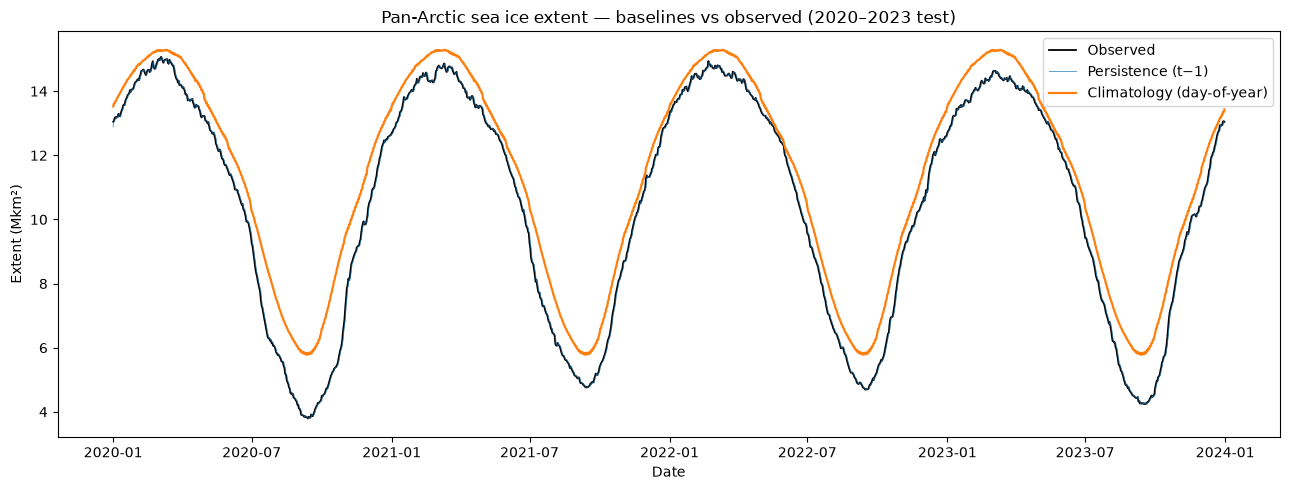

In [9]:
fig_dir = PROJECT_ROOT / "results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_true, color="black", lw=1.3, label="Observed")
ax.plot(test_dates, persistence_pred, color="tab:blue", lw=0.7, alpha=0.7, label="Persistence (t−1)")
ax.plot(test_dates, climatology_pred, color="tab:orange", lw=1.6, label="Climatology (day-of-year)")
ax.set_title("Pan-Arctic sea ice extent — baselines vs observed (2020–2023 test)")
ax.set_ylabel("Extent (Mkm²)")
ax.set_xlabel("Date")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(fig_dir / "baselines_2020_2023.png", dpi=120)
print("saved", fig_dir / "baselines_2020_2023.png")

## Findings

Evaluated on the **2020–2023 daily** pan-Arctic test set (1,461 days):

| Baseline | RMSE (Mkm²) | MAE | MAPE | Skill vs climatology | ACC |
|---|---|---|---|---|---|
| **Persistence** (t−1) | **0.087** | 0.069 | 0.77% | **+91.3%** | 0.985 |
| Climatology (day-of-year) | 0.997 | 0.866 | 11.6% | — | — |

**Persistence is the bar to beat.** At a one-day horizon, daily extent is so autocorrelated
that "tomorrow = today" reaches RMSE ≈ **0.087 Mkm²** — roughly **11× more accurate than
climatology** (skill +91%). Every later model (SARIMA, LSTM, Seq2Seq) must be denormalized to
Mkm² and shown to beat 0.087 here before it can be called useful.

**Climatology fails on the recent low-ice years.** A day-of-year mean (RMSE ≈ 1.0 Mkm²) cannot
track 2020–2023, which ran well below the historical seasonal cycle — its skill score vs
persistence is strongly negative (−10.5).

**Seasonality tells the real story.** Persistence is essentially season-independent
(winter RMSE 0.085, summer 0.084), while climatology degrades sharply in the melt season
(winter 0.724 → summer 1.086 Mkm²). Summer is the hard regime — exactly where climatology is
weakest and where a good model has to add value *over persistence*, not just over climatology.

> The persistence row's skill-vs-climatology of +0.913 and the climatology row's ACC of `nan`
> (its anomalies are zero by construction) are expected artifacts of each model serving as its
> own reference in `compute_all_metrics`.